In [1]:
import torch
import torch.nn as nn
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm
from einops import rearrange
from scipy.stats import spearmanr
from accelerate.hooks import ModelHook, remove_hook_from_module
from accelerate.hooks import add_hook_to_module, remove_hook_from_module
from PIL import Image

from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from utils import *
from text_utils import *
from transformers import (
    CLIPVisionModel, CLIPImageProcessor,
    ViTModel, ViTForImageClassification, ViTImageProcessor,
    ViTMAEForPreTraining, AutoImageProcessor,
    AutoProcessor, LlavaForConditionalGeneration,
    Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor,
    SamModel, SamProcessor, AutoModel, Gemma3ForConditionalGeneration,AutoConfig
)

/u/masar/conda-envs/geovit_fix/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.cuda.empty_cache()

In [3]:
name = "Qwen/Qwen2.5-VL-3B-Instruct"
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    name,
    torch_dtype=torch.bfloat16,
).to("cuda")
processor = AutoProcessor.from_pretrained(name)

Loading checkpoint shards: 100%|██████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  8.04it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
import json
import pandas as pd
def collect_coeffs(file_path):
    # Collect R² values from cluster files
    with open(file_path,"r") as file:
        data = json.load(file)
    df = pd.DataFrame.from_dict(data,orient="index")
    #identify last layer index
    last_layer = df.index[-1]
    last_layer_data = data[last_layer]
    last_layer_data["layer"]=int(last_layer)
    #get absolute coefficient value
    last_layer_data["absolute_latitude"] = np.absolute(last_layer_data["latitude_coefficients"])
    last_layer_data["absolute_longitude"] = np.absolute(last_layer_data["longitude_coefficients"])
    #negate the array to sort descending order
    last_layer_data["latitude_indexes"]= np.argsort(-last_layer_data["absolute_latitude"])
    last_layer_data["longitude_indexes"]= np.argsort(-last_layer_data["absolute_longitude"])
    norm_lat = (last_layer_data["absolute_latitude"]-np.min(last_layer_data["absolute_latitude"]))/(np.max(last_layer_data["absolute_latitude"])-np.min(last_layer_data["absolute_latitude"]))
    norm_lon = (last_layer_data["absolute_longitude"]-np.min(last_layer_data["absolute_longitude"]))/(np.max(last_layer_data["absolute_longitude"])-np.min(last_layer_data["absolute_longitude"]))
    last_layer_data["combined_indexes"] = np.argsort(-(norm_lat+norm_lon))

    #identify first layer index
    first_layer = df.index[0]
    first_layer_data = data[first_layer]
    first_layer_data["layer"]=int(first_layer)
    #get absolute coefficient value
    first_layer_data["absolute_latitude"] = np.absolute(first_layer_data["latitude_coefficients"])
    first_layer_data["absolute_longitude"] = np.absolute(first_layer_data["longitude_coefficients"])
    #negate the array to sort descending order
    first_layer_data["latitude_indexes"]= np.argsort(-first_layer_data["absolute_latitude"])
    first_layer_data["longitude_indexes"]= np.argsort(-first_layer_data["absolute_longitude"])
    norm_lat = (first_layer_data["absolute_latitude"]-np.min(first_layer_data["absolute_latitude"]))/(np.max(first_layer_data["absolute_latitude"])-np.min(first_layer_data["absolute_latitude"]))
    norm_lon = (first_layer_data["absolute_longitude"]-np.min(first_layer_data["absolute_longitude"]))/(np.max(first_layer_data["absolute_longitude"])-np.min(first_layer_data["absolute_longitude"]))
    first_layer_data["combined_indexes"] = np.argsort(-(norm_lat+norm_lon))
    
    #identify best_layer_index
    best_layer = df[df["R2"]==df[:-1]["R2"].max()].index[0]
    best_layer_data = data[best_layer]
    best_layer_data["layer"]=int(best_layer)
    best_layer_data["absolute_latitude"] = np.absolute(best_layer_data["latitude_coefficients"])
    best_layer_data["absolute_longitude"] = np.absolute(best_layer_data["longitude_coefficients"])
    best_layer_data["latitude_indexes"]= np.argsort(-best_layer_data["absolute_latitude"])
    best_layer_data["longitude_indexes"]= np.argsort(-best_layer_data["absolute_longitude"])
    norm_lat = (best_layer_data["absolute_latitude"]-np.min(best_layer_data["absolute_latitude"]))/(np.max(best_layer_data["absolute_latitude"])-np.min(best_layer_data["absolute_latitude"]))
    norm_lon = (best_layer_data["absolute_longitude"]-np.min(best_layer_data["absolute_longitude"]))/(np.max(best_layer_data["absolute_longitude"])-np.min(best_layer_data["absolute_longitude"]))
    best_layer_data["combined_indexes"] = np.argsort(-(norm_lat+norm_lon))
    return last_layer_data,best_layer_data,first_layer_data

In [5]:
def get_inputs(image,prompt=None):
    image = torch.from_numpy(image)
    messages =[
    {

      "role": "user",
      "content": [
          {"type": "image"},
          #{"type": "text", "text": "Which country was this image taken in? Please answer with only the name."},
        ],
    },
    ]
    if prompt:
        messages[0]["content"].append({"type":"text","text":prompt})
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = processor(
        text=[text],
        images=image.permute(2,0,1),
        padding=True,
        return_tensors="pt",
    )
    return inputs.to("cuda")

In [6]:
class ModifyHook(ModelHook):
    def post_forward(self, module, output):
        global gen_count
        if gen_count>=len(important_output_list):
            return output
        new_output = output[0]
        new_output[:,-1,indexes] = important_output_list[gen_count][0][:,-1,indexes]
        new_tup = (new_output,output[1])
        gen_count+=1
        return new_tup



class ExtractHook(ModelHook):
    def post_forward(self, module, output):
        important_output_list.append(output)
        return output

## Test Landmarks

In [7]:
dataset = HDF5ImageDataset("../vit/geocells_landmarks.hdf5", transform=None)

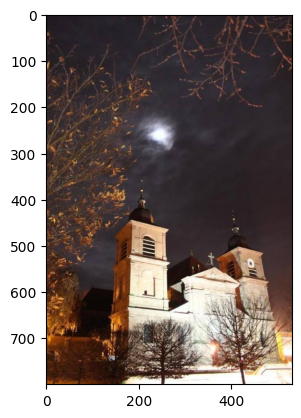

In [8]:
#pyramid, egypt
img = dataset[0]
plt.imshow(img)
plt.show()
Image.fromarray(img).save("./pictures/pyramid.png")

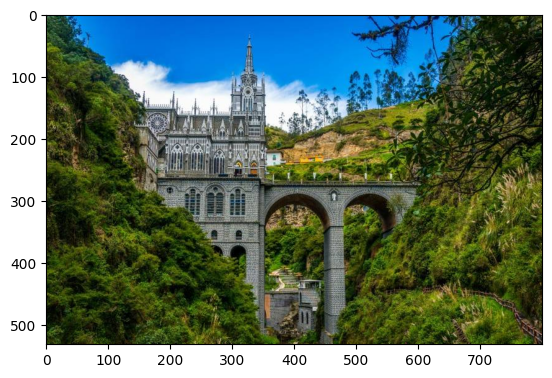

In [9]:
#fontana di trevi, rome
out_img = dataset[1]
plt.imshow(out_img)
plt.show()
Image.fromarray(out_img).save("./pictures/trevi.png")

In [10]:
last_layer_data,best_layer_data,first_layer_data = collect_coeffs("./results/geocells_08/Qwen2.5-VL-3B-Instruct/text_landmark_activation.json")

In [11]:

layer=first_layer_data["layer"]
data = first_layer_data
frac=0.5
alpha = 1
prompt=None

important_output_list =[]
indexes = data["combined_indexes"][:int(frac*len(data["combined_indexes"]))]
indexes = data["combined_indexes"][:int(frac*len(data["combined_indexes"]))]

gen_count=0


In [12]:
# Attach to desired layers to obtain the output
add_hook_to_module(model.model.layers[layer],ExtractHook())
with torch.no_grad():
    inputs = get_inputs(out_img,prompt=prompt)
    out=model.generate(**inputs,max_new_tokens=100,temperature=0.01)
    generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, out)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)
remove_hook_from_module(model.model.layers[layer])

['The image depicts the Santuario de las Lajas, also known as Las Lajas Sanctuary, located in Ipiales, Colombia. This is a stunning example of Gothic Revival architecture, featuring intricate stone carvings and a dramatic setting surrounded by lush greenery and mountains. The sanctuary is renowned for its impressive architecture and spiritual significance.']


Qwen2_5_VLDecoderLayer(
  (self_attn): Qwen2_5_VLSdpaAttention(
    (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
    (k_proj): Linear(in_features=2048, out_features=256, bias=True)
    (v_proj): Linear(in_features=2048, out_features=256, bias=True)
    (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
    (rotary_emb): Qwen2_5_VLRotaryEmbedding()
  )
  (mlp): Qwen2MLP(
    (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
    (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
    (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
    (act_fn): SiLU()
  )
  (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
  (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
)

In [13]:
add_hook_to_module(model.model.layers[layer],ModifyHook())
with torch.no_grad():
    inputs = get_inputs(img,prompt=prompt)
    out=model.generate(**inputs,max_new_tokens=100,temperature=0.01)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, out)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)
remove_hook_from_module(model.model.layers[layer])

['The image depicts a nightime view of a church with the visible in the moon. The church is a the of the city, and is the part of the the architecture.']


Qwen2_5_VLDecoderLayer(
  (self_attn): Qwen2_5_VLSdpaAttention(
    (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
    (k_proj): Linear(in_features=2048, out_features=256, bias=True)
    (v_proj): Linear(in_features=2048, out_features=256, bias=True)
    (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
    (rotary_emb): Qwen2_5_VLRotaryEmbedding()
  )
  (mlp): Qwen2MLP(
    (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
    (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
    (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
    (act_fn): SiLU()
  )
  (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
  (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
)